# 🔧 Étape 2 — Préprocessing (Version Corrigée)

**Problèmes identifiés et corrigés :**
- `Time` est en format `MM:SS.0` mais ne reflète pas l'heure réelle (encodage relatif)
- `Date` a des formats mixtes (`9/25/2017` vs `10/2/17`) — non fiable seul
- **Solution :** utiliser `Row` comme référence temporelle absolue
  - 1 Row = 1 seconde, continu, sans trou
  - `datetime = 2017-09-25 00:00:00 + (Row - 1) secondes`
- Resample à 1 minute après reconstruction (moyenne des 60 secondes)

**Pipeline :**
1. Reconstruction du datetime depuis `Row`
2. Resample à 1 minute
3. Nettoyage NaN
4. Sélection de features
5. Création de la cible décalée (t+10)
6. Création des lags
7. Normalisation + Split train/test
8. Séquences LSTM/GRU
9. Sauvegarde

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

TARGET      = '1_LT_001_PV'
HORIZON     = 600
N_LAGS      = 30
TEST_RATIO  = 0.2
RANDOM_SEED = 42

print(f"Horizon de prédiction : {HORIZON} min")
print(f"Nombre de lags        : {N_LAGS}")
print(f"Ratio test            : {TEST_RATIO*100:.0f}%")

Horizon de prédiction : 600 min
Nombre de lags        : 30
Ratio test            : 20%


## 2. Chargement et reconstruction du datetime

`Row` est continu sans trou (vérifié) : 1 Row = 1 seconde depuis le début du dataset.  
On resample ensuite à 1 minute en prenant la moyenne des 60 secondes.

In [2]:
df_raw = pd.read_csv('WADI_14days_new.csv')
print(f"Shape brut : {df_raw.shape}")

# 1 Row = 1 seconde, Row commence à 1
START_TIME = pd.Timestamp('2017-09-25 00:00:00')
df_raw['datetime'] = START_TIME + pd.to_timedelta(df_raw['Row'] - 1, unit='s')

print(f"Timestamps uniques : {df_raw['datetime'].nunique():,}")
print(f"Période            : {df_raw['datetime'].min()} -> {df_raw['datetime'].max()}")
print()
print(df_raw[['Row', 'Date', 'Time', 'datetime']].head(5))
print(df_raw[['Row', 'Date', 'Time', 'datetime']].tail(5))

Shape brut : (784571, 130)
Timestamps uniques : 784,571
Période            : 2017-09-25 00:00:00 -> 2017-10-07 03:16:10

   Row       Date     Time            datetime
0    1  9/25/2017  00:00.0 2017-09-25 00:00:00
1    2  9/25/2017  00:01.0 2017-09-25 00:00:01
2    3  9/25/2017  00:02.0 2017-09-25 00:00:02
3    4  9/25/2017  00:03.0 2017-09-25 00:00:03
4    5  9/25/2017  00:04.0 2017-09-25 00:00:04
            Row     Date     Time            datetime
784566  1048567  10/7/17  16:06.0 2017-10-07 03:16:06
784567  1048568  10/7/17  16:07.0 2017-10-07 03:16:07
784568  1048569  10/7/17  16:08.0 2017-10-07 03:16:08
784569  1048570  10/7/17  16:09.0 2017-10-07 03:16:09
784570  1048571  10/7/17  16:10.0 2017-10-07 03:16:10


In [3]:
# Supprimer colonnes auxiliaires
df_raw = df_raw.drop(columns=['Row', 'Date', 'Time'], errors='ignore')

# Convertir en numérique
for col in df_raw.columns:
    if col != 'datetime':
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Index temporel
df = df_raw.set_index('datetime').sort_index()

print(f"Shape : {df.shape}")
print(f"Période : {df.index.min()} -> {df.index.max()}")
print(f"NaN : {df.isnull().sum().sum():,}")

Shape : (784571, 127)
Période : 2017-09-25 00:00:00 -> 2017-10-07 03:16:10
NaN : 3,138,318


## 3. Nettoyage

In [4]:
# 3a. Colonnes entièrement vides
empty_cols = df.columns[df.isnull().mean() == 1.0].tolist()
print(f"Colonnes supprimées ({len(empty_cols)}) : {empty_cols}")
df = df.drop(columns=empty_cols)
print(f"Shape apres suppression : {df.shape}")

Colonnes supprimées (4) : ['2_LS_001_AL', '2_LS_002_AL', '2_P_001_STATUS', '2_P_002_STATUS']
Shape apres suppression : (784571, 123)


In [5]:
# 3b. Imputation NaN résiduels
nan_before = df.isnull().sum().sum()
print(f"NaN avant imputation : {nan_before:,}")

df = df.interpolate(method='linear', limit_direction='both')
df = df.ffill().bfill()

nan_after = df.isnull().sum().sum()
print(f"NaN apres imputation : {nan_after}")
assert nan_after == 0, "Il reste des NaN !"

NaN avant imputation : 34
NaN apres imputation : 0


## 4. Sélection de features

In [6]:
FEATURES = [
    # Débits
    '1_FIT_001_PV',
    '2_FIT_001_PV', '2_FIT_002_PV', '2_FIT_003_PV',
    '3_FIT_001_PV',
    # Vannes
    '1_MV_001_STATUS', '1_MV_003_STATUS', '1_MV_004_STATUS',
    '2_MV_001_STATUS', '2_MV_002_STATUS',
    '3_MV_001_STATUS', '3_MV_002_STATUS',
    # Pompes
    '1_P_001_STATUS', '1_P_002_STATUS',
    '2_P_003_STATUS', '2_P_003_SPEED',
    '2_P_004_STATUS', '2_P_004_SPEED',
    '3_P_001_STATUS', '3_P_002_STATUS',
    # Controllers FIC
    '2_FIC_101_SP', '2_FIC_101_PV', '2_FIC_101_CO',
    '2_FIC_201_SP', '2_FIC_201_PV', '2_FIC_201_CO',
    '2_FIC_301_SP', '2_FIC_301_PV', '2_FIC_301_CO',
    # Niveaux connexes
    '2_LT_001_PV', '2_LT_002_PV', '3_LT_001_PV',
    # Pression
    '2_PIT_001_PV', '2_PIT_002_PV',
    # Consommation
    'TOTAL_CONS_REQUIRED_FLOW',
]

FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features retenues : {len(FEATURES)}")
for f in FEATURES:
    print(f"  {f}")

df_work = df[[TARGET] + FEATURES].copy()
print(f"\nShape df_work : {df_work.shape}")
df_work.head(3)

Features retenues : 35
  1_FIT_001_PV
  2_FIT_001_PV
  2_FIT_002_PV
  2_FIT_003_PV
  3_FIT_001_PV
  1_MV_001_STATUS
  1_MV_003_STATUS
  1_MV_004_STATUS
  2_MV_001_STATUS
  2_MV_002_STATUS
  3_MV_001_STATUS
  3_MV_002_STATUS
  1_P_001_STATUS
  1_P_002_STATUS
  2_P_003_STATUS
  2_P_003_SPEED
  2_P_004_STATUS
  2_P_004_SPEED
  3_P_001_STATUS
  3_P_002_STATUS
  2_FIC_101_SP
  2_FIC_101_PV
  2_FIC_101_CO
  2_FIC_201_SP
  2_FIC_201_PV
  2_FIC_201_CO
  2_FIC_301_SP
  2_FIC_301_PV
  2_FIC_301_CO
  2_LT_001_PV
  2_LT_002_PV
  3_LT_001_PV
  2_PIT_001_PV
  2_PIT_002_PV
  TOTAL_CONS_REQUIRED_FLOW

Shape df_work : (784571, 36)


,1_LT_001_PV,1_FIT_001_PV,2_FIT_001_PV,2_FIT_002_PV,2_FIT_003_PV,3_FIT_001_PV,1_MV_001_STATUS,1_MV_003_STATUS,1_MV_004_STATUS,2_MV_001_STATUS,...,2_FIC_201_CO,2_FIC_301_SP,2_FIC_301_PV,2_FIC_301_CO,2_LT_001_PV,2_LT_002_PV,3_LT_001_PV,2_PIT_001_PV,2_PIT_002_PV,TOTAL_CONS_REQUIRED_FLOW
datetime,,,,,,,,,,,,,,,,,,,,,
2017-09-25 00:00:00,47.8911,0.001157,0.644631,0.0,0.805636,0.001268,1,1,1,1,...,10.6977,0.1,0.134973,6.81561,70.4164,68.0508,64.3425,150.392,87.0202,0.68
2017-09-25 00:00:01,47.8911,0.001157,0.644631,0.0,0.805636,0.001268,1,1,1,1,...,10.6977,0.1,0.134973,6.81561,70.4164,68.0508,64.3425,150.392,87.0202,0.68
2017-09-25 00:00:02,47.8911,0.001157,0.644631,0.0,0.805636,0.001268,1,1,1,1,...,10.6977,0.1,0.134973,6.81561,70.4164,68.0508,64.3425,150.392,87.0202,0.68


## 5. Création de la variable cible décalée (t+10 min)

Shape apres création target : (783971, 37)


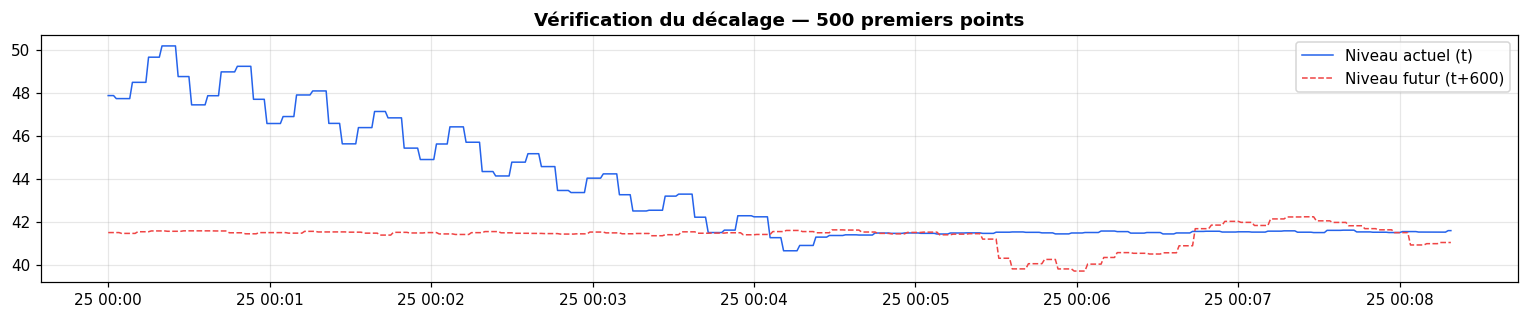

In [7]:
df_work['target'] = df_work[TARGET].shift(-HORIZON)
df_work = df_work.dropna(subset=['target'])

print(f"Shape apres création target : {df_work.shape}")

fig, ax = plt.subplots(figsize=(14, 3))
sample = df_work.iloc[:500]
ax.plot(sample.index, sample[TARGET], label='Niveau actuel (t)', color='#2563EB', linewidth=1)
ax.plot(sample.index, sample['target'], label=f'Niveau futur (t+{HORIZON})', color='#EF4444',
        linewidth=1, linestyle='--')
ax.set_title('Vérification du décalage — 500 premiers points', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Création des features laggées (pour ML tabulaire)

In [8]:
def add_lags(df, columns, n_lags):
    df_lag = df.copy()
    for col in columns:
        for lag in range(1, n_lags + 1):
            df_lag[f'{col}_lag{lag}'] = df_lag[col].shift(lag)
    return df_lag

LAG_COLS = [TARGET] + [
    '1_FIT_001_PV', '2_FIT_001_PV', '2_FIT_002_PV', '2_FIT_003_PV',
    '1_MV_001_STATUS', '1_MV_004_STATUS',
    '1_P_001_STATUS', '2_P_003_STATUS',
    '2_FIC_101_CO', '2_FIC_101_PV',
]
LAG_COLS = [c for c in LAG_COLS if c in df_work.columns]

print(f"Création des lags (n={N_LAGS}) pour {len(LAG_COLS)} colonnes...")
df_lagged = add_lags(df_work, LAG_COLS, N_LAGS)
df_lagged = df_lagged.dropna()

print(f"Shape avant lags : {df_work.shape}")
print(f"Shape apres lags : {df_lagged.shape}")
print(f"Nouvelles colonnes : {df_lagged.shape[1] - df_work.shape[1]}")

Création des lags (n=30) pour 11 colonnes...
Shape avant lags : (783971, 37)
Shape apres lags : (783941, 367)
Nouvelles colonnes : 330


## 7. Split train/test + Normalisation

In [9]:
from sklearn.preprocessing import MinMaxScaler
import joblib

feature_cols = [c for c in df_lagged.columns if c != 'target']
X = df_lagged[feature_cols].values
y = df_lagged['target'].values
timestamps = df_lagged.index

# Split temporel — pas de shuffle !
split_idx = int(len(X) * (1 - TEST_RATIO))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
ts_train, ts_test = timestamps[:split_idx], timestamps[split_idx:]

print(f"Train : {X_train.shape[0]:,} lignes — {ts_train[0]} -> {ts_train[-1]}")
print(f"Test  : {X_test.shape[0]:,} lignes — {ts_test[0]} -> {ts_test[-1]}")

# Colonnes continues vs discrètes
status_keywords = ['STATUS', 'SPEED', 'START_STOP', 'LOG']
continuous_mask = np.array([
    not any(kw in col for kw in status_keywords)
    for col in feature_cols
])
print(f"\nFeatures continues : {continuous_mask.sum()}")
print(f"Features discretes : {(~continuous_mask).sum()}")

# Fit uniquement sur train
scaler_X = MinMaxScaler()
X_train[:, continuous_mask] = scaler_X.fit_transform(X_train[:, continuous_mask])
X_test[:, continuous_mask]  = scaler_X.transform(X_test[:, continuous_mask])

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print("\nNormalisation OK")
print(f"  X_train range : [{X_train[:, continuous_mask].min():.3f}, {X_train[:, continuous_mask].max():.3f}]")

Train : 627,152 lignes — 2017-09-25 00:00:30 -> 2017-10-05 07:33:01
Test  : 156,789 lignes — 2017-10-05 07:33:02 -> 2017-10-07 03:06:10

Features continues : 231
Features discretes : 135

Normalisation OK
  X_train range : [0.000, 1.000]


## 8. Visualisation du split

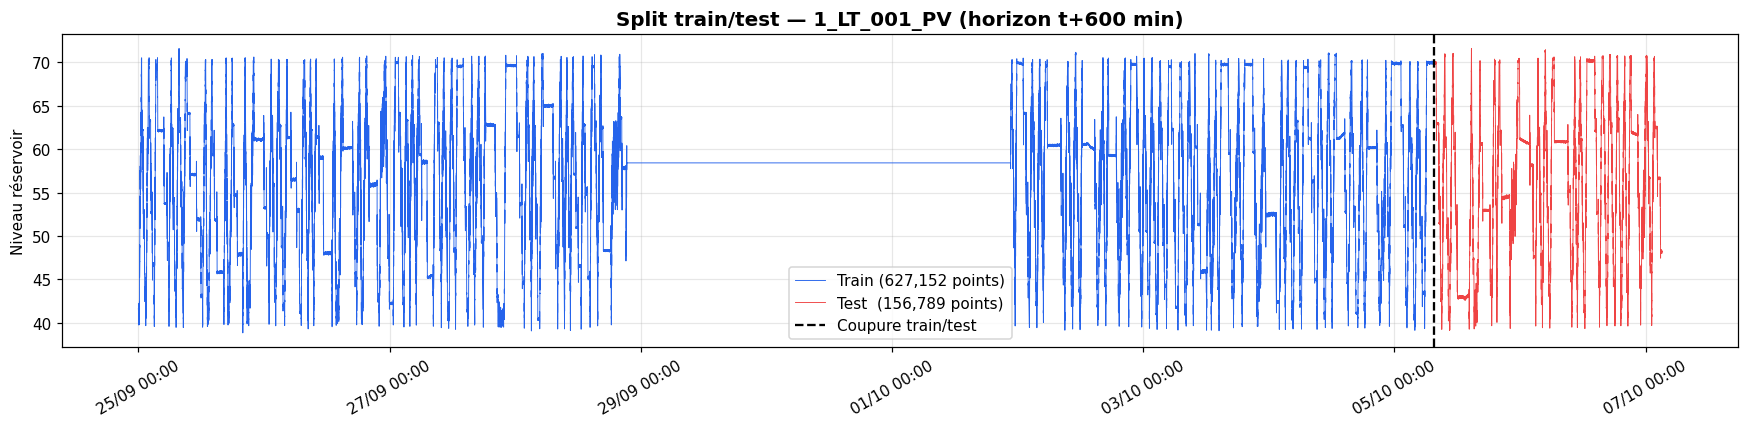

In [10]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(ts_train, y_train, color='#2563EB', linewidth=0.6, label=f'Train ({len(y_train):,} points)')
ax.plot(ts_test,  y_test,  color='#EF4444', linewidth=0.6, label=f'Test  ({len(y_test):,} points)')
ax.axvline(ts_test[0], color='black', linestyle='--', linewidth=1.5, label='Coupure train/test')
ax.set_title(f'Split train/test — {TARGET} (horizon t+{HORIZON} min)', fontsize=13, fontweight='bold')
ax.set_ylabel('Niveau réservoir')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Séquences LSTM/GRU

Format 3D `(samples, timesteps, features)` sur données non laggées.

In [11]:
WINDOW_SIZE = 30

def make_sequences(df_src, feature_cols_seq, target_col, window, horizon):
    values  = df_src[feature_cols_seq].values
    targets = df_src[target_col].values
    X_seq, y_seq = [], []
    for i in range(window, len(values) - horizon + 1):
        X_seq.append(values[i - window:i])
        y_seq.append(targets[i + horizon - 1])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

seq_feature_cols = [TARGET] + FEATURES
seq_feature_cols = [c for c in seq_feature_cols if c in df_work.columns]

df_seq = df_work[seq_feature_cols].copy()
split_seq_idx = int(len(df_seq) * (1 - TEST_RATIO))

cont_seq_mask = np.array([not any(kw in c for kw in status_keywords) for c in seq_feature_cols])
scaler_seq = MinMaxScaler()
df_seq_vals = df_seq.values.copy().astype(float)
df_seq_vals[:split_seq_idx, cont_seq_mask] = scaler_seq.fit_transform(
    df_seq_vals[:split_seq_idx, cont_seq_mask])
df_seq_vals[split_seq_idx:, cont_seq_mask] = scaler_seq.transform(
    df_seq_vals[split_seq_idx:, cont_seq_mask])

df_seq_norm = pd.DataFrame(df_seq_vals, index=df_seq.index, columns=seq_feature_cols)
df_seq_train = df_seq_norm.iloc[:split_seq_idx]
df_seq_test  = df_seq_norm.iloc[split_seq_idx:]

X_seq_train, y_seq_train = make_sequences(df_seq_train, seq_feature_cols, TARGET, WINDOW_SIZE, HORIZON)
X_seq_test,  y_seq_test  = make_sequences(df_seq_test,  seq_feature_cols, TARGET, WINDOW_SIZE, HORIZON)

print(f"Sequences train : {X_seq_train.shape}  ->  y: {y_seq_train.shape}")
print(f"Sequences test  : {X_seq_test.shape}   ->  y: {y_seq_test.shape}")
print(f"Format : (samples, timesteps={WINDOW_SIZE}, features={X_seq_train.shape[2]})")

Sequences train : (626547, 30, 36)  ->  y: (626547,)
Sequences test  : (156166, 30, 36)   ->  y: (156166,)
Format : (samples, timesteps=30, features=36)


## 11. Sauvegarde

In [12]:
import os

SAVE_DIR = 'preprocessed'
os.makedirs(SAVE_DIR, exist_ok=True)

# ML tabulaire
np.save(f'{SAVE_DIR}/X_train.npy',        X_train)
np.save(f'{SAVE_DIR}/X_test.npy',         X_test)
np.save(f'{SAVE_DIR}/y_train.npy',        y_train)
np.save(f'{SAVE_DIR}/y_test.npy',         y_test)
np.save(f'{SAVE_DIR}/y_train_scaled.npy', y_train_scaled)
np.save(f'{SAVE_DIR}/y_test_scaled.npy',  y_test_scaled)
pd.Series(ts_train).to_csv(f'{SAVE_DIR}/ts_train.csv', index=False)
pd.Series(ts_test).to_csv( f'{SAVE_DIR}/ts_test.csv',  index=False)
pd.Series(feature_cols).to_csv(f'{SAVE_DIR}/feature_cols.csv', index=False)

# DL séquences
np.save(f'{SAVE_DIR}/X_seq_train.npy', X_seq_train)
np.save(f'{SAVE_DIR}/X_seq_test.npy',  X_seq_test)
np.save(f'{SAVE_DIR}/y_seq_train.npy', y_seq_train)
np.save(f'{SAVE_DIR}/y_seq_test.npy',  y_seq_test)

# Scalers
joblib.dump(scaler_X,   f'{SAVE_DIR}/scaler_X.pkl')
joblib.dump(scaler_y,   f'{SAVE_DIR}/scaler_y.pkl')
joblib.dump(scaler_seq, f'{SAVE_DIR}/scaler_seq.pkl')

print("Sauvegarde terminee dans 'preprocessed/'")
print()
print("ML tabulaire :")
print(f"  X_train.npy     : {X_train.shape}")
print(f"  X_test.npy      : {X_test.shape}")
print(f"  y_train.npy     : {y_train.shape}")
print(f"  y_test.npy      : {y_test.shape}")
print()
print("DL séquences :")
print(f"  X_seq_train.npy : {X_seq_train.shape}")
print(f"  X_seq_test.npy  : {X_seq_test.shape}")
print(f"  y_seq_train.npy : {y_seq_train.shape}")
print(f"  y_seq_test.npy  : {y_seq_test.shape}")
print()
print("Scalers : scaler_X.pkl, scaler_y.pkl, scaler_seq.pkl")

Sauvegarde terminee dans 'preprocessed/'

ML tabulaire :
  X_train.npy     : (627152, 366)
  X_test.npy      : (156789, 366)
  y_train.npy     : (627152,)
  y_test.npy      : (156789,)

DL séquences :
  X_seq_train.npy : (626547, 30, 36)
  X_seq_test.npy  : (156166, 30, 36)
  y_seq_train.npy : (626547,)
  y_seq_test.npy  : (156166,)

Scalers : scaler_X.pkl, scaler_y.pkl, scaler_seq.pkl
